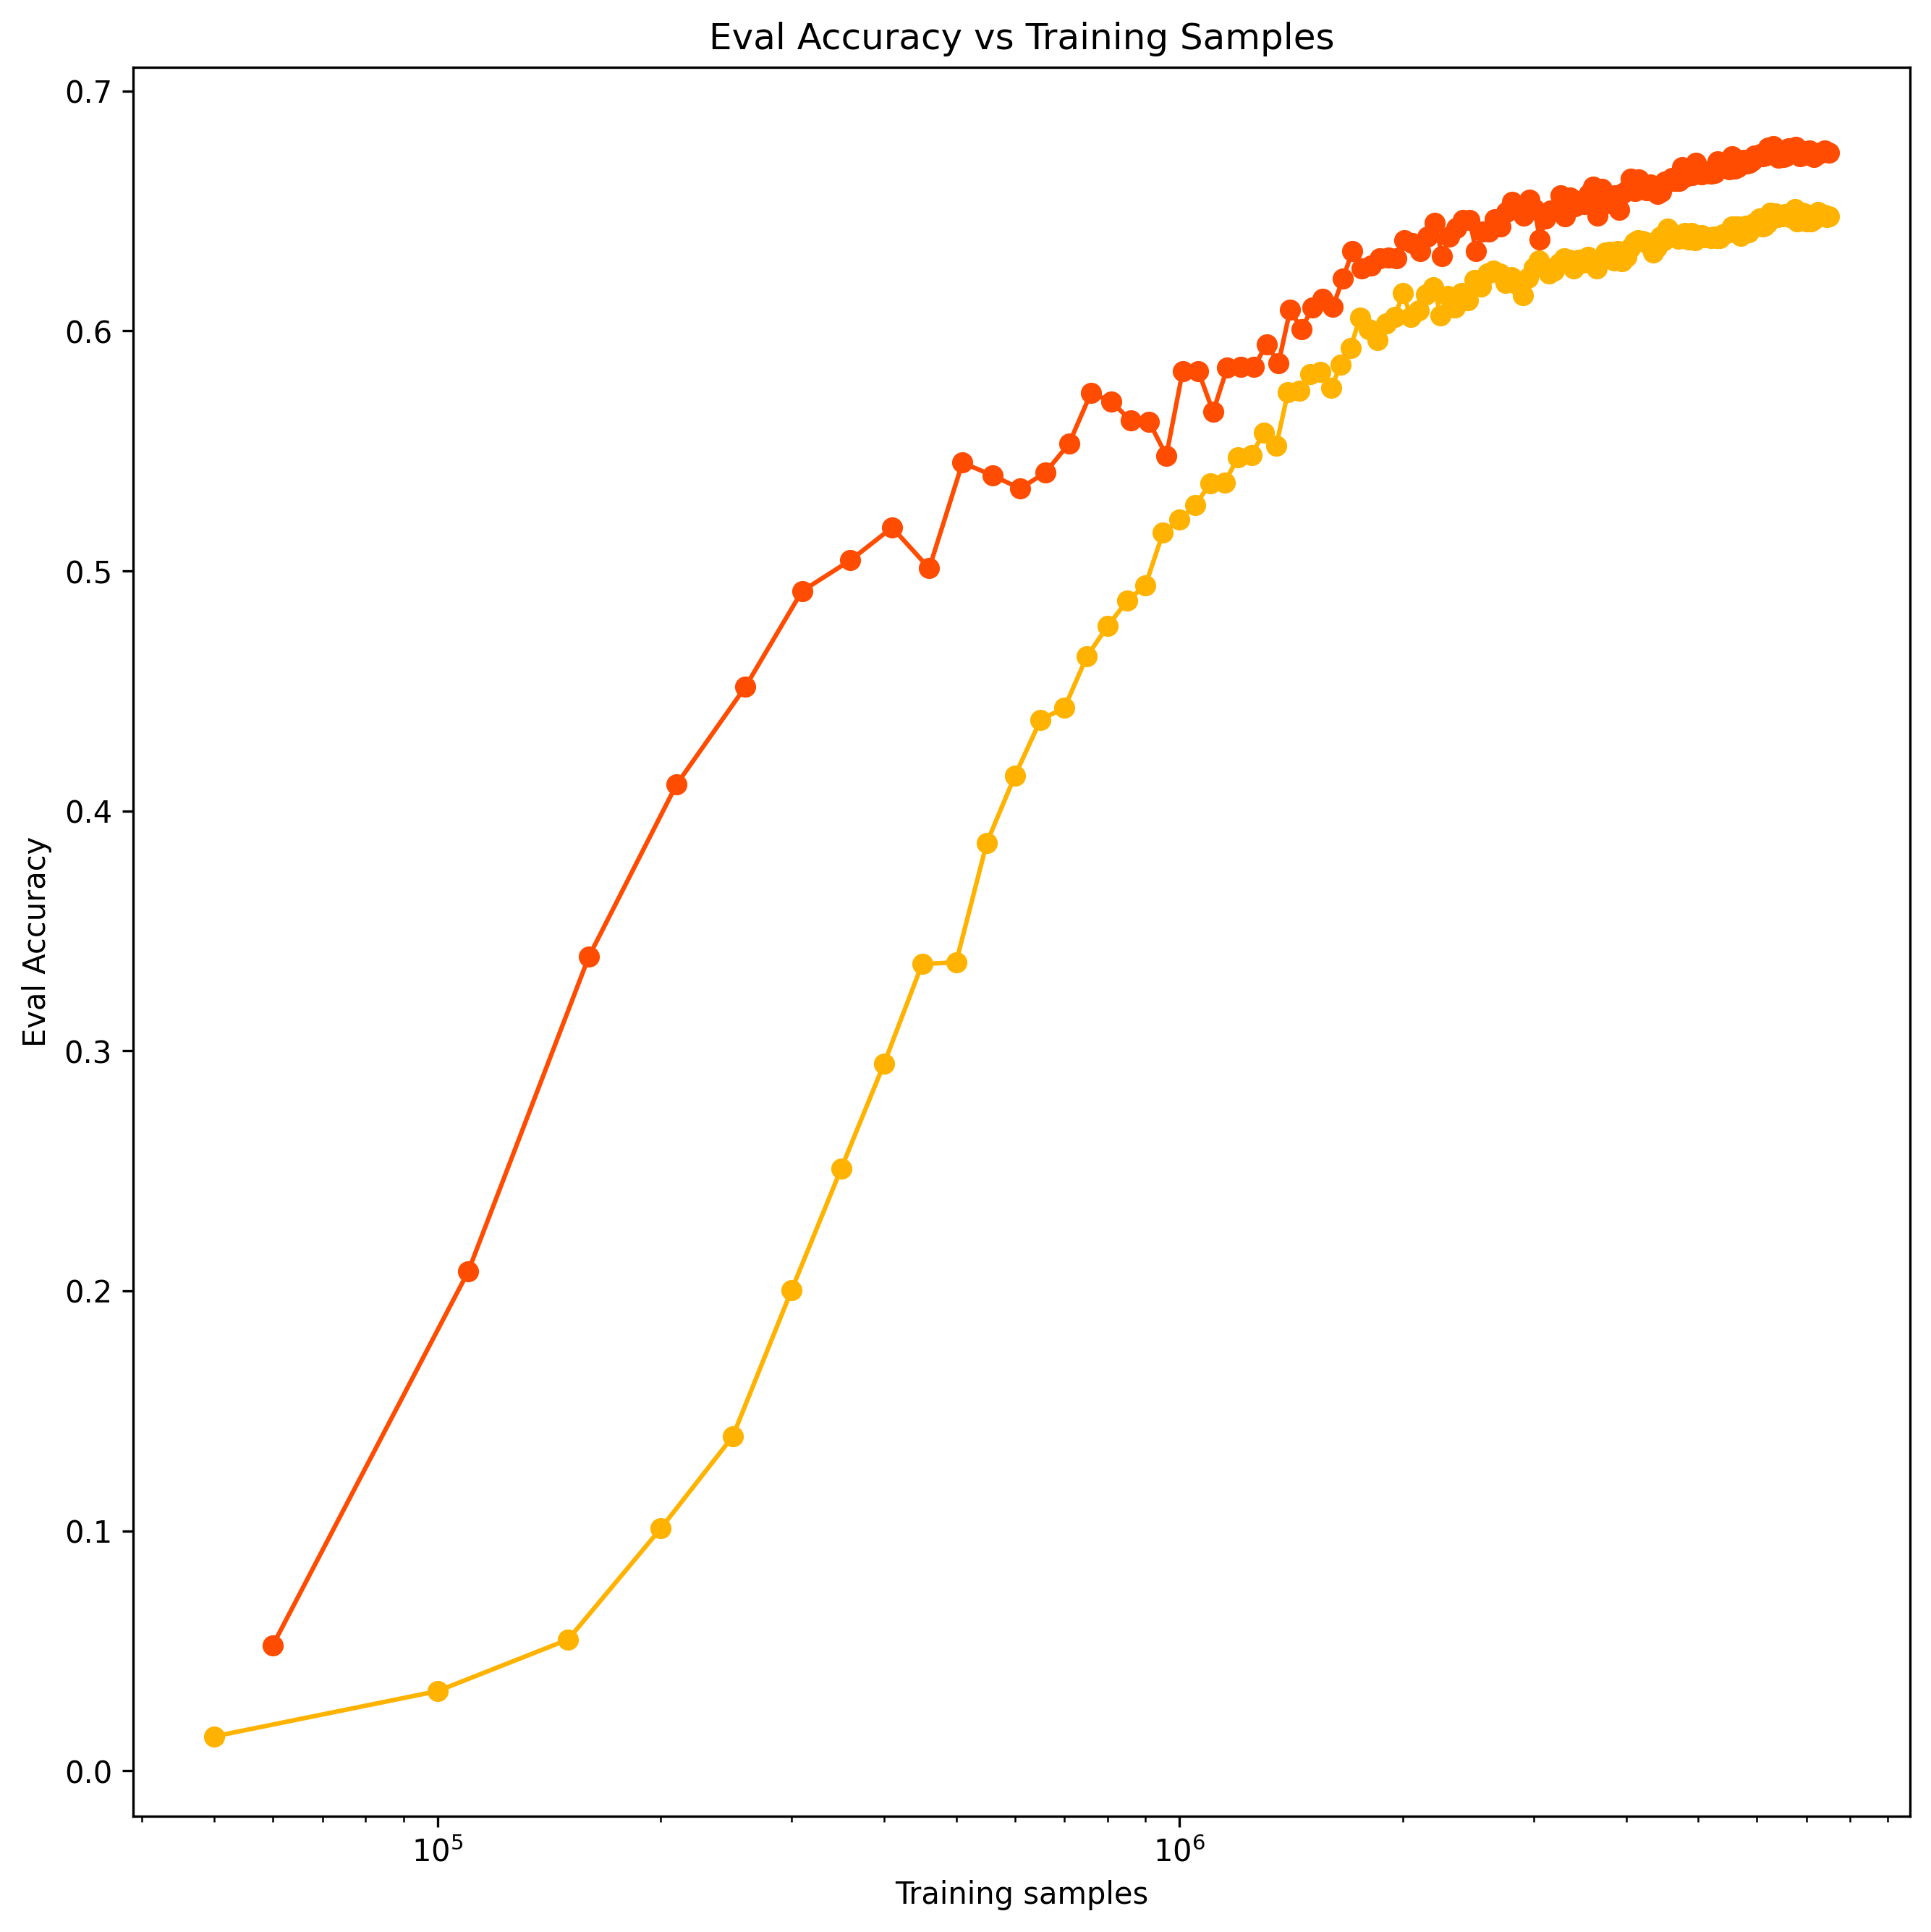

In [6]:
import json
import matplotlib.pyplot as plt
import os

# Paths to your models
model_base = '/home/apassi1/bottleneck_training_runs'
model_a = 'lr0.001_randomFalse_staticNormFalse_shuffled'
model_b = 'lr0.001_randomFalse_staticNormTrue_10k_sys_freezeBefore1'

state_files = [
    (model_a, os.path.join(model_base, model_a, 'trainer_state.json')),
    (model_b, os.path.join(model_base, model_b, 'trainer_state.json'))
]

def extract_samples_and_acc(statefile, offset=0):
    with open(statefile, 'r') as f:
        state = json.load(f)
    samples = []
    accs = []
    for record in state['log_history']:
        if 'eval_accuracy' in record:
            epoch = record['epoch']
            # Multiply by 50k and add offset if specified
            x_val = epoch * 50000 + offset
            samples.append(x_val)
            accs.append(record['eval_accuracy'])
    return samples, accs

plt.figure(figsize=(9,9), dpi =300)

# Flip the autumn colormap colors for the two lines
colors = plt.cm.autumn([0.7, 0.3])
labels = [model_a, model_b]

for i, (name, path) in enumerate(state_files):
    offset = 0
    if name == 'lr0.001_randomFalse_staticNormTrue_10k_sys_freezeBefore1':
        offset = 10000
    samples, accs = extract_samples_and_acc(path, offset=offset)
    plt.plot(samples, accs, marker='o', color=colors[i], label=labels[i])

plt.xlabel('Training samples')
plt.ylabel('Eval Accuracy')
plt.title('Eval Accuracy vs Training Samples')
# plt.legend()
plt.tight_layout()
plt.xscale('log')
plt.show()